# Closed-loop simulation: constrained vs. unconstrained control law

For each example, this simulates the **closed loop** `xdot = f(x) + g(x) u(x)` under both control
laws and compares their **performance**:

- **ours (constrained)** — `sop_bounded_control_<sys>_result.py`
- **unconstrained** — `sop_bounded_control_<sys>_unconstrained.py`

Both come from the _same_ `solvesop` run (consistent conditions; regenerate with
`matlab -batch "addpath('matlab'); regenerate_all_controllers"`). Reported per controller:
**success rate** (reach target while staying in the safe set), whether the control stays
**within bound along the trajectory**, and the control effort. Dynamics/sets come from
`../python/systems.py`.

Why simulate (not just compare the control _fields_): the worst-case `|u|` over the whole region
can exceed the bound even where the closed loop never goes; the trajectory tells us what the
controller actually does.


In [1]:
import sys, os, importlib.util
import numpy as np, sympy as sp
import matplotlib.pyplot as plt

ROOT = os.getcwd()
for _ in range(4):
    if os.path.isdir(os.path.join(ROOT, "controllers")) and os.path.isdir(
        os.path.join(ROOT, "python")
    ):
        break
    ROOT = os.path.dirname(ROOT)
for sub in ("python",):
    p = os.path.join(ROOT, sub)
    if p not in sys.path:
        sys.path.insert(0, p)
CTRL = os.path.join(ROOT, "controllers")
import importlib, systems as S

importlib.reload(S)
print("ROOT:", ROOT)

ROOT: /home/jianqiang/Downloads/reach_avoid_backstepping_MPC


## 1. Configuration


In [2]:
CONFIG = {
    "dubins_car": dict(
        sysfn=S.dubins_system,
        ours="sop_bounded_control_dubins_car_result.py",
        uncon="sop_bounded_control_dubins_car_unconstrained.py",
    ),
    "manipulator": dict(
        sysfn=S.manipulator_system,
        ours="sop_bounded_control_acrobot_result.py",
        uncon="sop_bounded_control_acrobot_unconstrained.py",
    ),
}
N_IC = 30  # initial conditions per controller


def load_u_opt(fname):
    spec = importlib.util.spec_from_file_location("m", os.path.join(CTRL, fname))
    m = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(m)
    return sp.Matrix(m.u_opt)


def sample_ics(sysd, n, seed=42, pool=20000):
    np.random.seed(seed)
    lo, hi = sysd["lo"], sysd["hi"]
    dim = len(sysd["state"])
    sub = {sysd["y"][0]: sysd["h"][0], sysd["y"][1]: sysd["h"][1]}
    safe = sp.lambdify(sysd["state"], sp.sympify(sysd["safe_y"]).subs(sub), "numpy")
    targ = sp.lambdify(sysd["state"], sp.sympify(sysd["target_y"]).subs(sub), "numpy")
    X = np.random.rand(pool, dim) * (hi - lo) + lo
    sv = np.atleast_1d(np.squeeze(safe(*X.T)))
    tv = np.atleast_1d(np.squeeze(targ(*X.T)))
    return X[(sv >= 0) & (tv > 0)][:n]

## 2. Simulate both controllers and summarize

Success = reaches the target while staying in the safe set. "within bound" = `max|u|` along the
trajectory stays within the reference input bound.


In [3]:
results = {}
rows = []
for name, cfg in CONFIG.items():
    sysd = cfg["sysfn"]()
    ics = sample_ics(sysd, N_IC)
    print(f"\n=== {name}: {len(ics)} ICs x 2 controllers ===")
    for tag, fn in [("ours", cfg["ours"]), ("unconstrained", cfg["uncon"])]:
        cb = S.make_callables(sysd, load_u_opt(fn))
        recs = [S.simulate(sysd, cb, x0) for x0 in ics]
        results[(name, tag)] = dict(sysd=sysd, cb=cb, ics=ics, recs=recs)
        ok = [r for r in recs if np.all(np.isfinite(r["max_abs_u"]))]
        succ = (
            np.mean([r["reached"] and r["stayed_safe"] for r in recs]) if recs else 0.0
        )
        ub = np.array(sysd["u_bound"])
        within = np.mean([np.all(r["max_abs_u"] <= ub) for r in ok]) if ok else 0.0
        mau = (
            np.array([r["max_abs_u"] for r in ok])
            if ok
            else np.zeros((0, len(sysd["channels"])))
        )
        row = dict(
            system=name,
            controller=tag,
            success_pct=round(100 * succ, 1),
            within_bound_pct=round(100 * within, 1),
        )
        for i, ch in enumerate(sysd["channels"]):
            row[f"mean_max|{ch}|"] = (
                round(float(mau[:, i].mean()), 2) if len(mau) else np.nan
            )
        rows.append(row)
        msg = "  ".join(
            f"{k}={v}" for k, v in row.items() if k not in ("system", "controller")
        )
        print(f"  {tag:14s} {msg}")
try:
    import pandas as pd

    display(pd.DataFrame(rows))
except Exception:
    pass


=== dubins_car: 30 ICs x 2 controllers ===
  ours           success_pct=60.0  within_bound_pct=16.7  mean_max|u1 (omega)|=46.98  mean_max|u2 (a)|=4.39
  unconstrained  success_pct=60.0  within_bound_pct=16.7  mean_max|u1 (omega)|=47.01  mean_max|u2 (a)|=4.39

=== manipulator: 30 ICs x 2 controllers ===
  ours           success_pct=100.0  within_bound_pct=0.0  mean_max|tau1|=4080.62  mean_max|tau2|=561.43
  unconstrained  success_pct=96.7  within_bound_pct=0.0  mean_max|tau1|=4104.22  mean_max|tau2|=591.37


,system,controller,success_pct,within_bound_pct,mean_max|u1 (omega)|,mean_max|u2 (a)|,mean_max|tau1|,mean_max|tau2|
0,dubins_car,ours,60.0,16.7,46.98,4.39,NaN,NaN
1,dubins_car,unconstrained,60.0,16.7,47.01,4.39,NaN,NaN
2,manipulator,ours,100.0,0.0,NaN,NaN,4080.62,561.43
3,manipulator,unconstrained,96.7,0.0,NaN,NaN,4104.22,591.37


## 3. Sample trajectories (output space) — ours vs. unconstrained

Overlaid on the safe-set (red) and target-set (orange) boundaries.


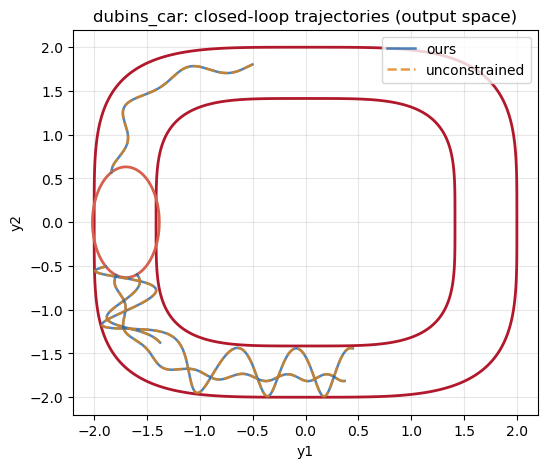

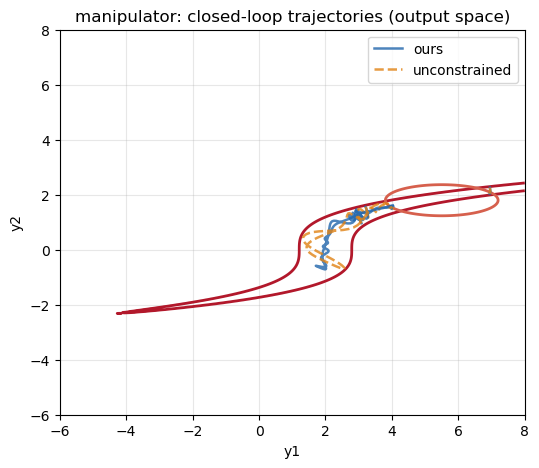

In [4]:
for name, cfg in CONFIG.items():
    sysd = cfg["sysfn"]()
    y1, y2 = sysd["y"]
    safe_y = sp.lambdify([y1, y2], sysd["safe_y"], "numpy")
    targ_y = sp.lambdify([y1, y2], sysd["target_y"], "numpy")
    ro = results[(name, "ours")]
    ru = results[(name, "unconstrained")]
    # ICs where ours succeeded (for a meaningful overlay), up to 4
    idx = [i for i, r in enumerate(ro["recs"]) if r["reached"] and r["stayed_safe"]][:4]
    hx = ro["cb"]["h"]
    fig, ax = plt.subplots(figsize=(6, 5))
    gx = (
        np.linspace(-6, 8, 400)
        if name == "manipulator"
        else np.linspace(-2.2, 2.2, 400)
    )
    gy = (
        np.linspace(-6, 8, 400)
        if name == "manipulator"
        else np.linspace(-2.2, 2.2, 400)
    )
    GX, GY = np.meshgrid(gx, gy)
    ax.contour(GX, GY, safe_y(GX, GY), levels=[0], colors="#b2182b", linewidths=2)
    ax.contour(GX, GY, targ_y(GX, GY), levels=[0], colors="#d6604d", linewidths=2)
    for i in idx:
        for r, c, lab in [
            (ro["recs"][i], "#2166ac", "ours"),
            (ru["recs"][i], "#e08214", "unconstrained"),
        ]:
            if len(r["X"]) == 0:
                continue
            Yt = np.array(hx(*r["X"].T)).reshape(2, -1)
            ax.plot(
                Yt[0],
                Yt[1],
                color=c,
                lw=1.8,
                alpha=0.8,
                label=lab if i == idx[0] else None,
                ls="-" if lab == "ours" else "--",
            )
    ax.set_title(f"{name}: closed-loop trajectories (output space)")
    ax.set_xlabel("y1")
    ax.set_ylabel("y2")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

## 4. Control inputs along a trajectory — ours vs. unconstrained (with bound band)


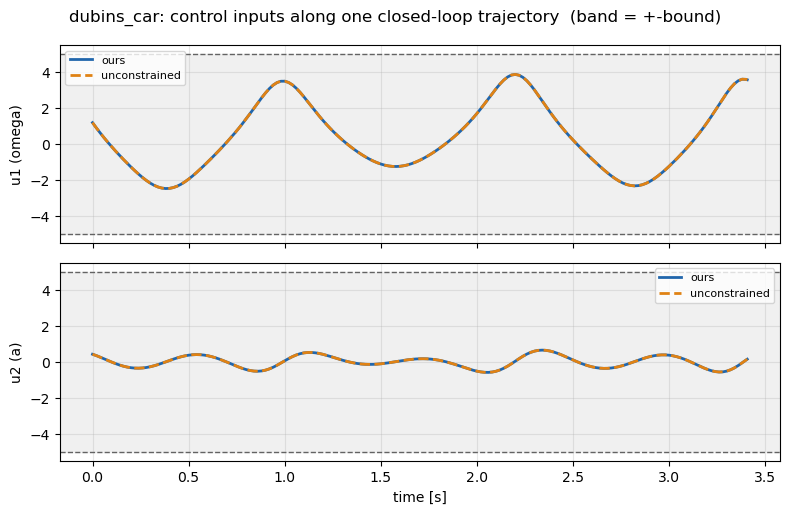

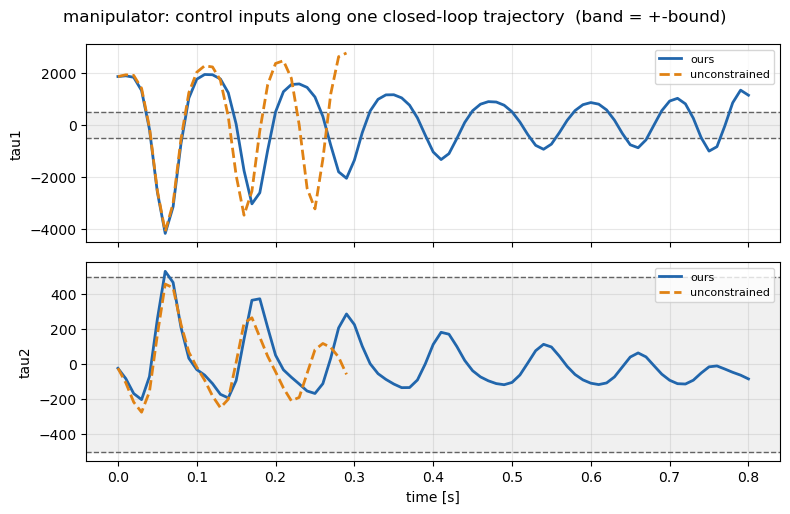

In [5]:
for name, cfg in CONFIG.items():
    sysd = cfg["sysfn"]()
    ro = results[(name, "ours")]
    ru = results[(name, "unconstrained")]
    idx = [i for i, r in enumerate(ro["recs"]) if r["reached"] and r["stayed_safe"]]
    if not idx:
        print(f"{name}: no successful trajectory to plot")
        continue
    i = idx[0]
    ch = sysd["channels"]
    ub = sysd["u_bound"]
    fig, axes = plt.subplots(
        len(ch), 1, figsize=(8, 2.6 * len(ch)), sharex=True, squeeze=False
    )
    for c in range(len(ch)):
        ax = axes[c][0]
        ax.axhspan(-ub[c], ub[c], color="#f0f0f0")
        ax.axhline(ub[c], color="#636363", ls="--", lw=1)
        ax.axhline(-ub[c], color="#636363", ls="--", lw=1)
        for r, col, lab, ls in [
            (ro["recs"][i], "#2166ac", "ours", "-"),
            (ru["recs"][i], "#e08214", "unconstrained", "--"),
        ]:
            if len(r["X"]) == 0 or "U" not in r:
                continue
            ax.plot(r["t"], r["U"][c], color=col, lw=2, ls=ls, label=lab)
        ax.set_ylabel(ch[c])
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    axes[-1][0].set_xlabel("time [s]")
    fig.suptitle(
        f"{name}: control inputs along one closed-loop trajectory  (band = +-bound)"
    )
    fig.tight_layout()
    plt.show()